In [ ]:
import random

# K-means

## Environment Setting

In [ ]:
# This get the RAPIDS-Colab install files and test check your GPU.  Run this and the next cell only.
# Please read the output of this cell.  If your Colab Instance is not RAPIDS compatible, it will warn you and give you remediation steps.
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py

Cloning into 'rapidsai-csp-utils'...
remote: Enumerating objects: 603, done.
remote: Counting objects: 100% (169/169), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 603 (delta 131), reused 82 (delta 82), pack-reused 434 (from 3)
Receiving objects: 100% (603/603), 199.38 KiB | 1.52 MiB/s, done.
Resolving deltas: 100% (305/305), done.
Installing RAPIDS remaining 25.08 libraries
Using Python 3.12.12 environment at: /usr
  × No solution found when resolving dependencies:
  ╰─▶ Because only libucx-cu12==1.19.0 is available and ucx-py-cu12==0.45.0
      depends on libucx-cu12>=1.15.0,<1.19, we can conclude that
      ucx-py-cu12==0.45.0 cannot be used.
      And because only the following versions of ucx-py-cu12 are available:
          ucx-py-cu12<0.45.dev0
          ucx-py-cu12==0.45.0
      and cugraph-cu12==25.8.0 depends on ucx-py-cu12>=0.45.dev0, we can
      conclude that cugraph-cu12==25.8.0 cannot be used.
      And because only the following versions of cugra

In [ ]:
import cuml
cuml.__version__

'25.08.00'

In [ ]:
import cudf
import numpy as np
import pandas as pd
import cupy as cp
from cuml.cluster import KMeans as C_KMeans
from cuml import KMeans as C_KMeans2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, kmeans_plusplus

## Q1. 使用 scikit-learn (cpu_based) 記錄 1~15 次迭代的 SSE

In [ ]:
# ===== 1) 建立測試資料 (CPU 上) =====
s_X = pd.read_csv("/content/2025clustering.csv")
print("資料形狀:", s_X.shape)
print("欄位:", s_X.columns.tolist())
print(s_X.head())

資料形狀: (2002, 9)
欄位: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
    MedInc  HouseAge   AveRooms    AveBedrms  Population  AveOccup  Latitude  \
0  10.0000       100   5.000000    50.000000        2000  8.000000     40.00   
1   8.0000       300  70.000000  1000.000000      199999  7.000000     50.00   
2   3.8141        52   5.568000     1.034667         908  2.421333     34.08   
3   1.5076        24   3.192563     1.087649        1566  2.079681     33.77   
4   3.0952        23   5.801325     1.101545        1210  2.671082     38.65   

   Longitude  MedHouseVal  
0     -10.00        6.000  
1    -100.00        7.000  
2    -118.35        3.420  
3    -118.20        1.458  
4    -121.32        1.577  


In [ ]:
# ===== 2) 工具函式：逐次限制 max_iter，記錄 inertia_ =====
def sse_by_iteration(s_X, n_clusters, init, max_steps, random_state, n_init):
    """
    sklearn KMeans

    INPUT: k-means參數
    OUTPUT: 每個iterate的結果紀錄(LIST)

    Source: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
    """
    sse_hist = []
    for i in range(1, max_steps + 1):
        km = KMeans(
            n_clusters=n_clusters,
            init=init,
            max_iter=i,
            random_state=random_state,
            n_init=n_init
        )
        km.fit(s_X)
        sse_hist.append(km.inertia_)
    return sse_hist

In [ ]:
# ===== 3) 設定K_means 取得 SSE 歷史 =====
n_clusters = 4
init = "random"
random_state = 42
n_init = 1
max_steps = 15
sse_random = sse_by_iteration(s_X, n_clusters=n_clusters, init=init, max_steps=max_steps, random_state=random_state, n_init=n_init)

In [ ]:
# ===== 4) 印出數據 =====(不要修改此程式碼)
print("Iteration\tSSE(Random)\t")
for i in range(max_steps):
    print(f"{i+1}\t\t{sse_random[i]:.6f}")

Iteration	SSE(Random)	
1		39646581942.409752
2		39125577029.084435
3		38481324738.088669
4		37335045278.510307
5		35098939335.770897
6		20921485191.055584
7		831162414.854293
8		768968804.074474
9		724240805.217447
10		688539273.840542
11		659328035.122456
12		639523849.047609
13		619799401.232390
14		602128544.372001
15		591401742.743661


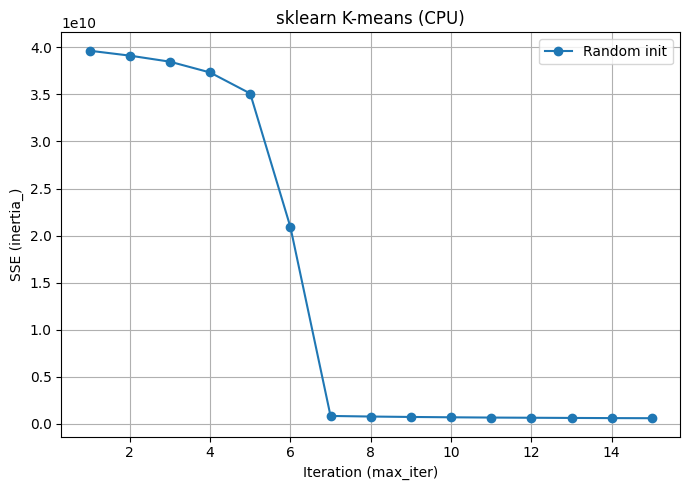

In [ ]:
# ===== 5) 畫圖比較 =====(不要修改此程式碼)
plt.figure(figsize=(7,5))
plt.plot(range(1, max_steps+1), sse_random, marker='o', label='Random init')

plt.xlabel("Iteration (max_iter)")
plt.ylabel("SSE (inertia_)")
plt.title("sklearn K-means (CPU)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Q2. 使用 cuML (GPU_based) 記錄 1~15 次迭代的 SSE

In [ ]:
# ===== 1) 建立測試資料 (在 GPU 上) =====
c_X = cudf.read_csv("/content/2025clustering.csv")
print("資料形狀:", c_X.shape)
print("欄位:", c_X.columns.tolist())
print(c_X.head())

資料形狀: (2002, 9)
欄位: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
    MedInc  HouseAge   AveRooms    AveBedrms  Population  AveOccup  Latitude  \
0  10.0000       100   5.000000    50.000000        2000  8.000000     40.00   
1   8.0000       300  70.000000  1000.000000      199999  7.000000     50.00   
2   3.8141        52   5.568000     1.034667         908  2.421333     34.08   
3   1.5076        24   3.192563     1.087649        1566  2.079681     33.77   
4   3.0952        23   5.801325     1.101545        1210  2.671082     38.65   

   Longitude  MedHouseVal  
0     -10.00        6.000  
1    -100.00        7.000  
2    -118.35        3.420  
3    -118.20        1.458  
4    -121.32        1.577  


In [ ]:
# ===== 2) 工具函式：逐次限制 max_iter，記錄 inertia_ =====
def sse_by_iteration(c_X, n_clusters, init, max_steps, random_state, n_init):
    """
    cuML

    INPUT: k-means參數
    OUTPUT: 每個iterate的結果紀錄(LIST)

    Source: https://docs.rapids.ai/api/cuml/stable/api/#k-means-clustering
    """
    sse_hist = []
    for i in range(1, max_steps + 1):
        km = C_KMeans2(
            n_clusters=n_clusters,
            init=init,
            max_iter=i,
            random_state=random_state,
            n_init=n_init
        )
        km.fit(s_X)
        sse_hist.append(km.inertia_)
    return sse_hist

In [ ]:
# ===== 3) 取得 SSE 歷史 =====
n_clusters = 4
init = "random"
max_steps = 15
random_state = 42
n_init = 1
sse_random = sse_by_iteration(s_X, n_clusters=n_clusters, init=init, max_steps=max_steps, random_state=random_state, n_init=n_init)

In [ ]:
# ===== 4) 印出數據 =====(不要修改此程式碼)
print("Iteration\tSSE(Random)\t")
for i in range(max_steps):
    print(f"{i+1}\t\t{sse_random[i]:.6f}\t")

Iteration	SSE(Random)	
1		39802597175.762939	
2		39927323521.780533	
3		38699345806.979263	
4		37993887257.271919	
5		30508657226.752064	
6		36348437906.322929	
7		711484389.137779	
8		839153443.546782	
9		741351960.844539	
10		781423758.329490	
11		645425193.788860	
12		651024473.202585	
13		622564453.766583	
14		593423730.838291	
15		579521343.590095	


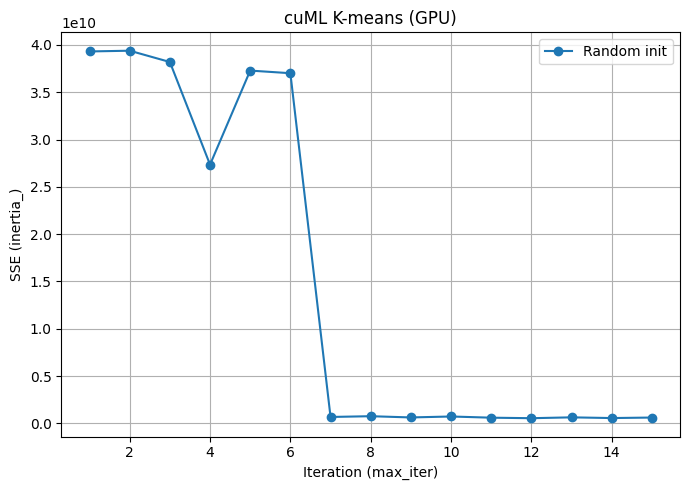

In [ ]:
# ===== 5) 畫圖比較 =====(不要修改此程式碼)
plt.figure(figsize=(7,5))
plt.plot(range(1, max_steps+1), sse_random, marker='o', label='Random init')
plt.xlabel("Iteration (max_iter)")
plt.ylabel("SSE (inertia_)")
plt.title("cuML K-means (GPU)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Q3, Q4 使用 cuML (GPU_based) 記錄 1~15 次迭代的 SSE，並固定初始centroid

In [ ]:
# ===== 2) 工具函式：逐次限制 max_iter，記錄 inertia_ =====
def sse_by_iteration(c_X, n_clusters, init, max_steps, random_state, n_init):
    """
    cuML

    INPUT: k-means參數
    OUTPUT: 每個iterate的結果紀錄(LIST)

    Source: https://docs.rapids.ai/api/cuml/stable/api/#k-means-clustering
    """
    sse_hist = []

    # 更改Q1程式碼，使用cuml.KMeans套件，執行kmeans演算法，，並回答Q3、Q4問題
    for i in range(1, max_steps + 1):
        km = C_KMeans2(
            n_clusters=n_clusters,
            init=init,
            max_iter=i,
            random_state=random_state,
            n_init=n_init
        )
        km.fit(s_X)
        sse_hist.append(km.inertia_)
    return sse_hist

In [ ]:
# ===== 3) 取得 SSE 歷史 =====
n_clusters = 4
init = c_X.iloc[[10, 110, 1110, 1500]]
max_steps = 15
random_state = 42
n_init = 1
sse_random = sse_by_iteration(s_X, n_clusters=n_clusters, init=init, max_steps=max_steps, random_state=random_state, n_init=n_init)

In [ ]:
# ===== 4) 印出數據 =====(不要修改此程式碼)
print("Iteration\tSSE(Random)\t")
for i in range(max_steps):
    print(f"{i+1}\t\t{sse_random[i]:.6f}\t")

Iteration	SSE(Random)	
1		38976517209.377800	
2		38286026780.773491	
3		36955120988.631516	
4		33839678502.548779	
5		9410077020.117382	
6		869053804.845116	
7		799674151.012546	
8		746585910.871874	
9		708829534.959438	
10		676029431.473970	
11		650112664.908001	
12		632329189.354400	
13		611748440.375633	
14		596790000.818763	
15		587429774.073407	


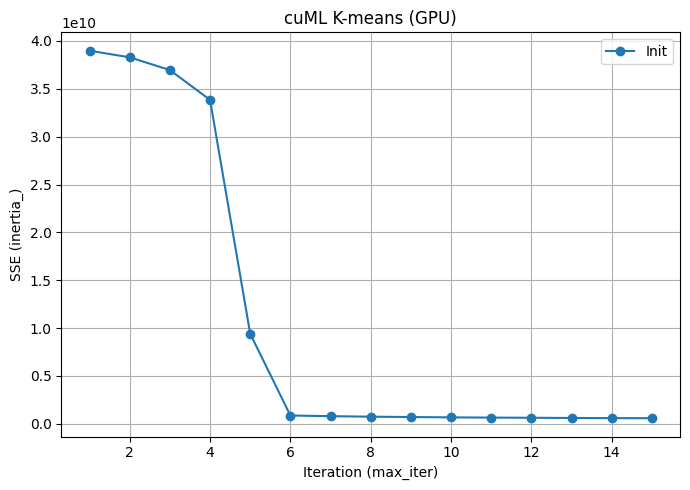

In [ ]:
# ===== 5) 畫圖比較 =====(不要修改此程式碼)
plt.figure(figsize=(7,5))
plt.plot(range(1, max_steps+1), sse_random, marker='o', label='Init')

plt.xlabel("Iteration (max_iter)")
plt.ylabel("SSE (inertia_)")
plt.title("cuML K-means (GPU)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Q5 & Q6 紀錄cluster包含的資料點數量

使用 scikit-learn (cpu_based)

In [ ]:
n_clusters = 6
max_steps = 999
random_state = 42
n_init = 1
s_X = pd.read_csv("/content/2025clustering.csv")
init_centers = s_X.iloc[[10,50,110,1200,1500,1800]]
#------------------------------------------------------------------------#

# 使用sklearn.cluster.KMeans套件，執行kmeans演算法，，並回答Q5、Q6問題
s_km = KMeans(
    n_clusters = n_clusters,
    init = init_centers,
    random_state = random_state,
    n_init = n_init,
    max_iter = max_steps,
)
s_km.fit(s_X)

#------------------------------------------------------------------------#
s_X['cluster'] = s_km.labels_
cluster_count = s_X['cluster'].value_counts().sort_values(ascending=False)

cluster_list = cluster_count.tolist()

print(f"scikit-learn (CPU_based)套件: {', '.join(map(str, cluster_list))}")

scikit-learn (CPU_based)套件: 766, 692, 400, 122, 21, 1


使用 cuML (GPU_based) 並固定初始centroid

In [ ]:
n_clusters = 6
max_steps = 999
random_state = 42
n_init = 1
c_X = cudf.read_csv("/content/2025clustering.csv")
init_centers = c_X.iloc[[10,50,110,1200,1500,1800]]
#------------------------------------------------------------------------#

# 使用cuml.KMeans套件，執行kmeans演算法，，並回答Q5、Q6問題
c_km = C_KMeans2(
    n_clusters = n_clusters,
    init = init_centers,
    random_state = random_state,
    n_init = n_init,
    max_iter = max_steps,
)
c_km.fit(c_X)

#------------------------------------------------------------------------#
c_X['cluster'] = c_km.labels_
cluster_count = c_X['cluster'].value_counts().sort_values(ascending=False)

cluster_list = cluster_count.to_pandas().tolist()

print(f"cuML (GPU_based)套件: {', '.join(map(str, cluster_list))}")

cuML (GPU_based)套件: 763, 696, 399, 122, 21, 1


# Q7  使用 scikit-learn (cpu_based)和cuML (GPU_based) 記錄 從分1到12 群的 SSE


CPU

In [ ]:
# ===== 2) 工具函式：逐次限制 max_iter，記錄 inertia_ =====

def sse_by_k(s_X, n_clusters, init, max_steps, random_state, n_init):
    """
    sklearn KMeans

    INPUT: k-means參數
    OUTPUT: 每個iterate的結果紀錄(LIST)

    Source: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
    """
    sses = []

    # 使用sklearn.KMeans套件，執行kmeans演算法，並回答Q7問題
    for k in range(1, n_clusters + 1):
        km = KMeans(
            n_clusters=k,
            init=init,
            random_state=random_state,
            n_init=n_init,
            max_iter=max_steps
        )
        km.fit(s_X)
        sses.append(km.inertia_)
    return sses

In [ ]:
# ===== 3) 設定K_means 取得 SSE 歷史 =====
n_clusters = 12
init='random'
max_steps = 15
random_state = 42
n_init = 1
sse_random = sse_by_k(s_X, n_clusters, init, max_steps, random_state, n_init)


In [ ]:
# ===== 4) 印出數據 =====(不要修改此程式碼)
print("Iteration\tSSE(Random)\t")
for i in range(n_clusters):
    print(f"{i+1}\t\t{sse_random[i]:.6f}\t")

Iteration	SSE(Random)	
1		41528394295.219612	
2		2089479855.943135	
3		1016030759.869330	
4		591403502.545063	
5		414669262.892235	
6		302893213.298527	
7		246661469.256999	
8		239250532.779837	
9		229969429.439393	
10		213830273.819000	
11		208681513.064536	
12		203844656.793774	


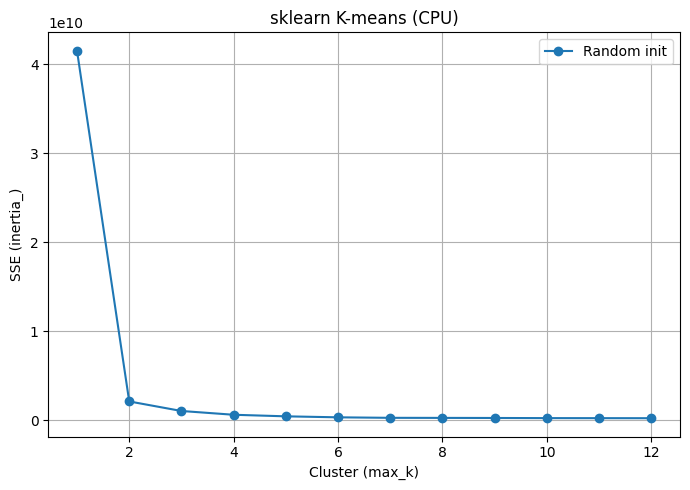

In [ ]:
# ===== 5) 畫圖比較 =====(不要修改此程式碼)
plt.figure(figsize=(7,5))
plt.plot(range(1, n_clusters+1), sse_random, marker='o', label='Random init')
plt.xlabel("Cluster (max_k)")
plt.ylabel("SSE (inertia_)")
plt.title("sklearn K-means (CPU)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


GPU

In [ ]:
def sse_by_k(c_X, n_clusters, init_indices, max_steps, random_state, n_init):

    sse_hist = []

    # 使用cuml.KMeans套件，執行kmeans演算法，，並回答Q7問題
    for k in range(1, n_clusters + 1):
      initial_centroids = c_X.iloc[init_centers_index[:k]]
      c_km = C_KMeans2(
          n_clusters=k,
          init=initial_centroids,
          random_state=random_state,
          n_init=n_init,
          max_iter=max_steps
          )
      c_km.fit(c_X)
      sse_hist.append(c_km.inertia_)

    return sse_hist

In [ ]:
# ===== 3) 取得 SSE 歷史 =====
n_clusters = 12
init_centers_index = [390, 885, 923, 931, 1123, 1163, 1351, 1556, 1610, 1619, 1778, 1994] # 分k群，使用init_centers_index中的前k個資料作為初始點
max_steps = 15
random_state = 42
n_init = 1
sse_random_cuda = sse_by_k(c_X, n_clusters=n_clusters, init_indices=init_centers_index, max_steps=max_steps, random_state=random_state, n_init=n_init)

In [ ]:
# ===== 4) 印出數據 =====(不要修改此程式碼)
print("Iteration\tSSE(Random)\t")
for i in range(n_clusters):
    print(f"{i+1}\t\t{sse_random_cuda[i]:.6f}\t")

Iteration	SSE(Random)	
1		41528394299.551872	
2		2089479860.290958	
3		1012687973.096461	
4		583137018.396347	
5		354279685.881803	
6		281631576.523059	
7		230420307.576095	
8		210566705.070808	
9		190067533.090157	
10		167074144.589939	
11		163739955.011367	
12		146918008.986834	


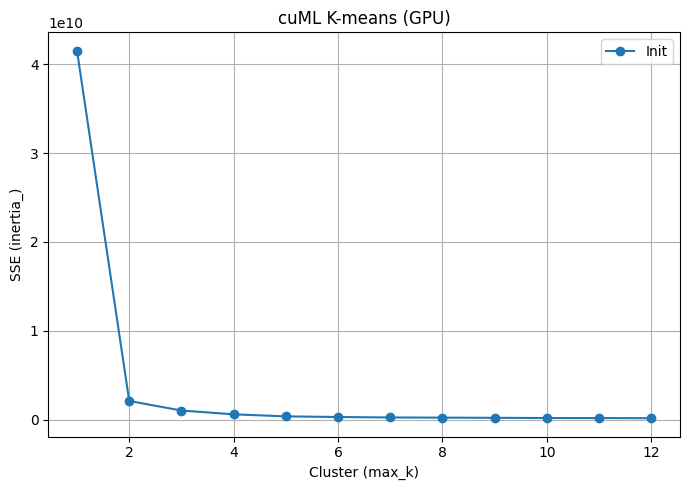

In [ ]:
# ===== 5) 畫圖比較 =====(不要修改此程式碼)
plt.figure(figsize=(7,5))
plt.plot(range(1, n_clusters+1), sse_random_cuda, marker='o', label='Init')

plt.xlabel("Cluster (max_k)")
plt.ylabel("SSE (inertia_)")
plt.title("cuML K-means (GPU)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Multi-class classification

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.tree as tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Removed 'Unnamed: 0' from training data
Removed 'Unnamed: 0' from test data
Data preprocessing completed!

Training set size: 594 samples (99.0%)
Validation set size: 6 samples (1.0%)


Default_entropy:
Parameters: {'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'entropy'}

Training accuracy: 1.0000
Validation accuracy: 1.0000
Overfitting gap: 0.0000

Max Depth=3_entropy:
Parameters: {'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'entropy'}

Training accuracy: 0.9529
Validation accuracy: 1.0000
Overfitting gap: -0.0471

Max Depth=5_entropy:
Parameters: {'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'entropy'}

Training accuracy: 0.9764
Validation accuracy: 1.0000
Overfitting gap: -0.0236

Default_gini:
Parameters: {'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'gini'}

Training accuracy: 1.0000
Validation accuracy: 1.0000
Overfitting gap: 0.0000

Max Depth=3_gini

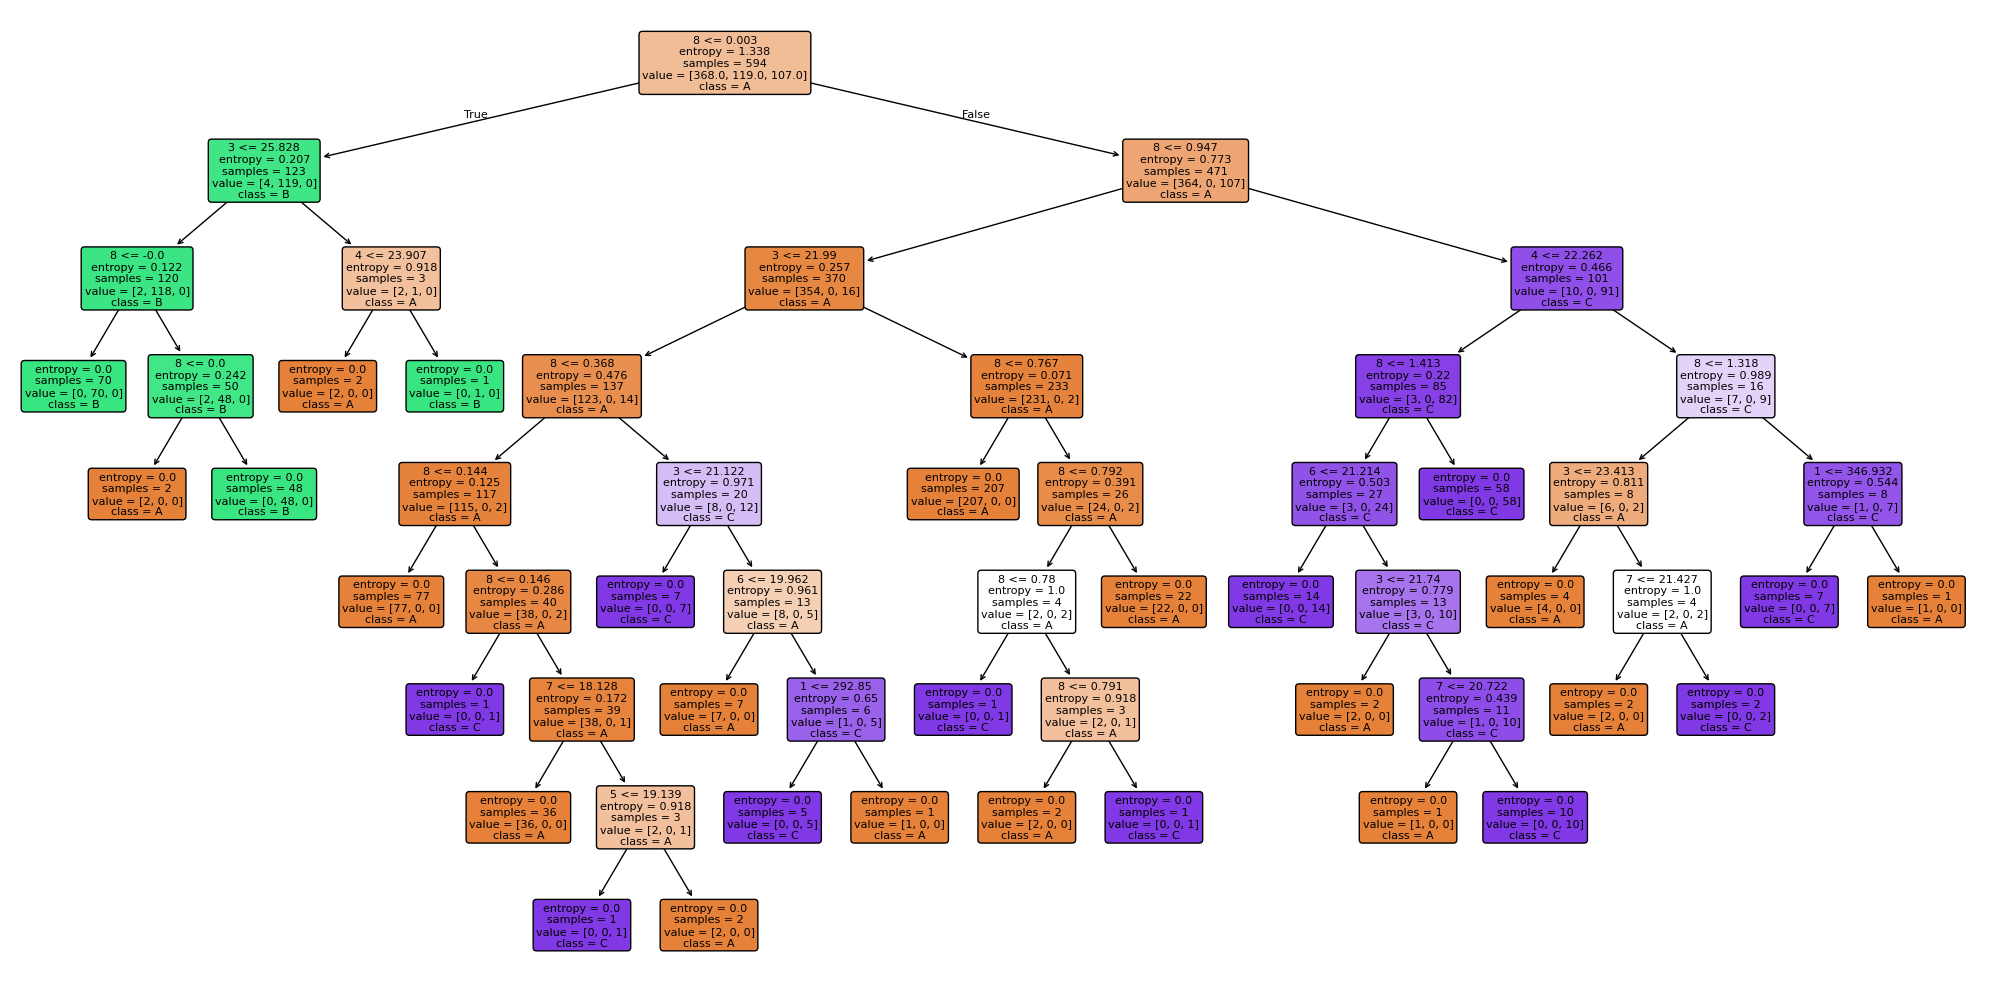


Max-depth=6_entropy:
Parameters: {'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'entropy'}

Training accuracy: 0.9933
Validation accuracy: 1.0000
Overfitting gap: -0.0067
Decision tree of max_depth=6 model:



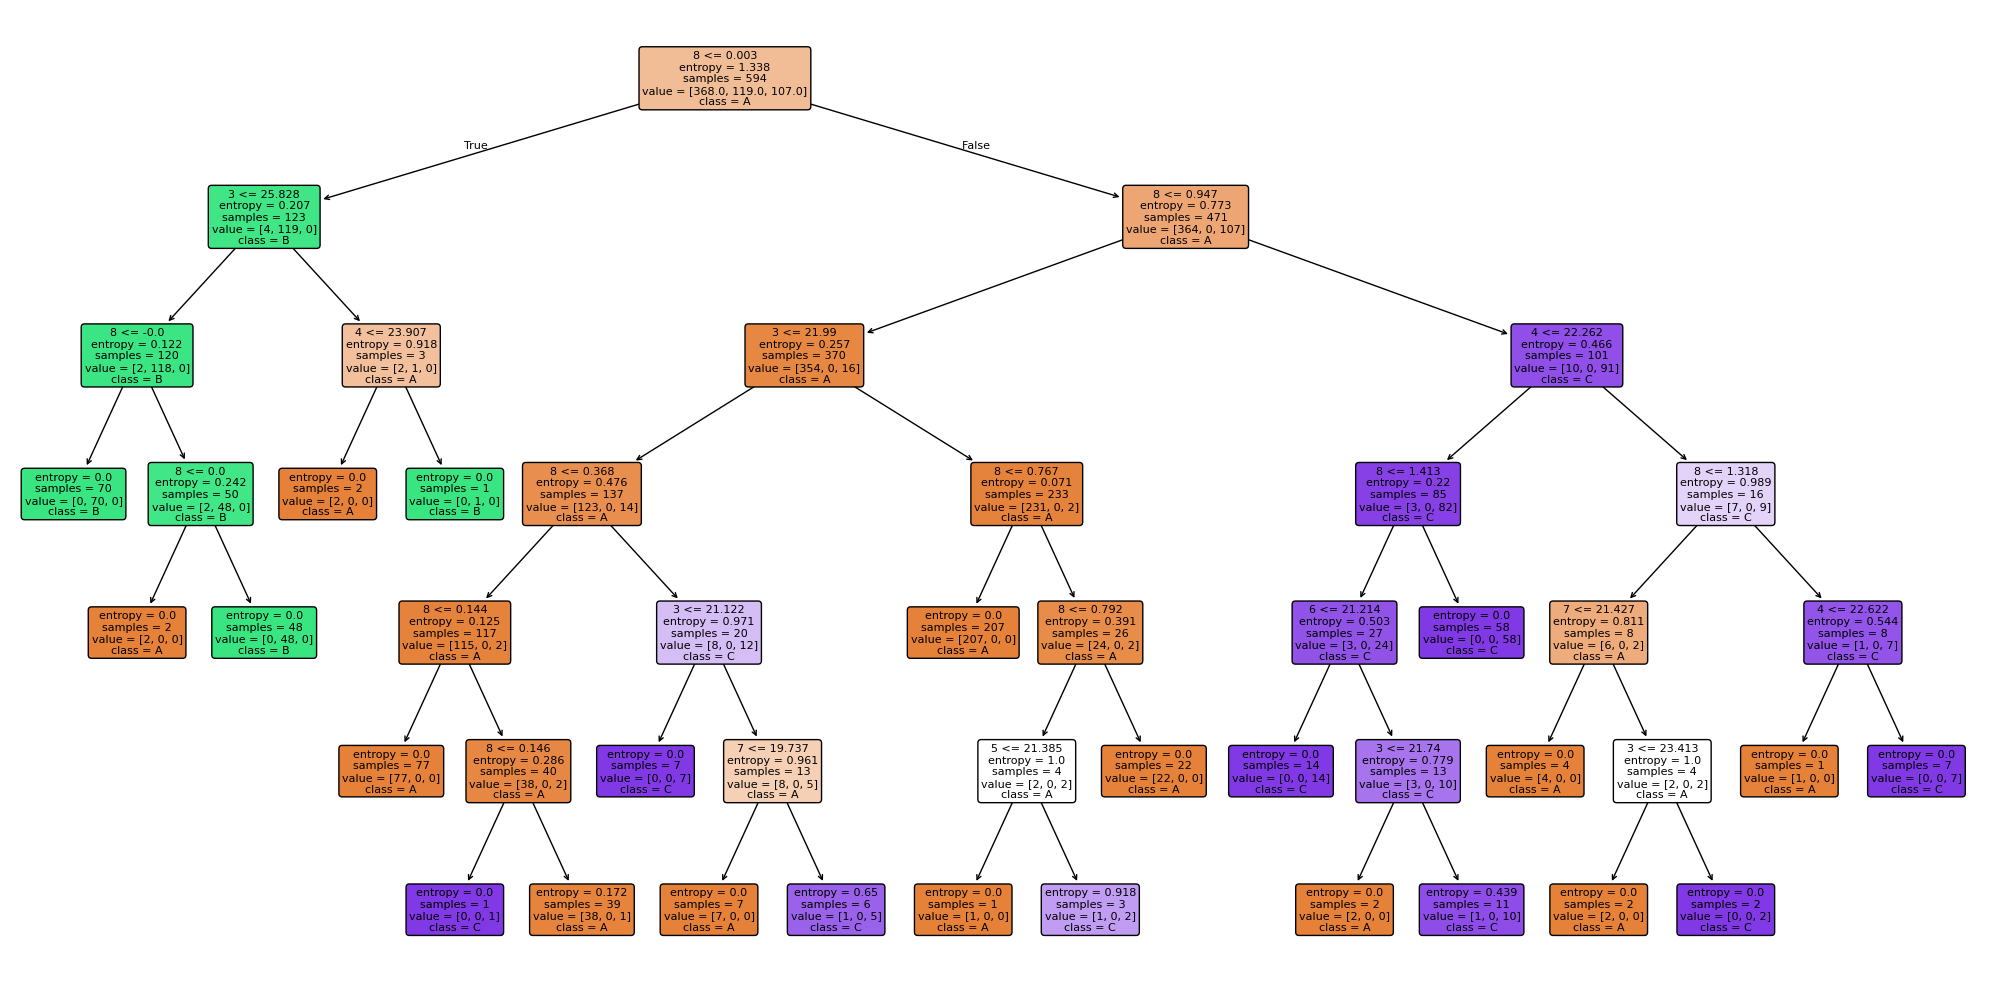


BEST MODEL: Max-depth=6_entropy

Training Accuracy: 0.9933 (99.33%)
Validation Accuracy: 1.0000 (100.00%)
Overfitting Gap: -0.0067

Validation Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         4
           B       1.00      1.00      1.00         1
           C       1.00      1.00      1.00         1

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6


Confusion Matrix (Validation Set):
[[4 0 0]
 [0 1 0]
 [0 0 1]]

Predictions generated!
Number of predictions: 400

Prediction distribution:
class
A    238
B     76
C     86
Name: count, dtype: int64

Predictions saved to 'predictions.csv'


In [13]:
# Step 1: Load Data
train_df = pd.read_csv("/content/hw2_tree_train.csv")
test_df = pd.read_csv("/content/hw2_tree_test.csv")

train_data = train_df.loc[:, train_df.columns != 'class']
test_data = test_df.loc[:, test_df.columns != 'class']
labels_train = train_df['class']

# Step 2: Data Preprocessing

# Remove index column if present
if 'Unnamed: 0' in train_data.columns:
    train_data = train_data.drop('Unnamed: 0', axis=1)
    print("Removed 'Unnamed: 0' from training data")

if 'Unnamed: 0' in test_data.columns:
    test_data = test_data.drop('Unnamed: 0', axis=1)
    print("Removed 'Unnamed: 0' from test data")

# Replacing INF values with mean values
train_data = train_data.replace(np.inf, np.nan)
train_data = train_data.fillna(value=train_data.values.mean())

test_data = test_data.replace(np.inf, np.nan)
test_data = test_data.fillna(value=test_data.values.mean())

print("Data preprocessing completed!\n")

# Step 3: Split training data (99% train, 1% validation)

X_train, X_val, y_train, y_val = train_test_split(
    train_data, labels_train,
    test_size=0.01,  # 1% validation
    random_state=42,
    stratify=labels_train
)

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(train_data)*100:.1f}%)")
print(f"Validation set size: {X_val.shape[0]} samples ({X_val.shape[0]/len(train_data)*100:.1f}%)\n")

# Step 4: Train Decision Tree with Pruning Parameters
# scikit-learn DecisionTreeClassifier
# ->try 3 different parameter settings
# ->Pick the best one

models_config = {
    "Default_entropy": {
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "criterion": "entropy"
    },
    "Max Depth=3_entropy": {
        "max_depth": 3,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "criterion": "entropy"
    },
    "Max Depth=5_entropy": {
        "max_depth": 5,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "criterion": "entropy"
    },
    "Default_gini": {
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "criterion": "gini"
    },
    "Max Depth=3_gini": {
        "max_depth": 3,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "criterion": "entropy"
    },
    "Max Depth=5_gini": {
        "max_depth": 5,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "criterion": "entropy"
    }
}

best_accuracy = 0
best_model_name = ""
best_model = None

for model_name, params in models_config.items():
    print(f"\n{model_name}:")
    print(f"Parameters: {params}")

    clf = DecisionTreeClassifier(**params, random_state=42)
    clf.fit(X_train, y_train)

    # Predictions
    y_train_pred = clf.predict(X_train)
    y_val_pred = clf.predict(X_val)

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)

    print(f"\nTraining accuracy: {train_acc:.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")
    print(f"Overfitting gap: {train_acc - val_acc:.4f}")

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_model_name = model_name
        best_model = clf

# Print best_model for further judgement
print("Decision tree of best_model:\n")
plt.figure(figsize=(20, 10))
tree.plot_tree(
    best_model,
    feature_names=train_data.columns,
    class_names=[str(c) for c in sorted(labels_train.unique())],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.tight_layout()
plt.show()

# Try:
# Set max-depth=6 to avoid potential overfitting
models_config_fixDepth = {
    "Max-depth=6_entropy": {
        "max_depth": 6,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "criterion": "entropy"
    },
  }

for model_name, params in models_config_fixDepth.items():
    print(f"\n{model_name}:")
    print(f"Parameters: {params}")

    clf = DecisionTreeClassifier(**params, random_state=42)
    clf.fit(X_train, y_train)

    # Predictions
    y_train_pred = clf.predict(X_train)
    y_val_pred = clf.predict(X_val)

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)

    print(f"\nTraining accuracy: {train_acc:.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")
    print(f"Overfitting gap: {train_acc - val_acc:.4f}")

    best_accuracy = val_acc
    best_model_name = model_name
    best_model = clf

# Print max_depth=6 model for final evaluation
print("Decision tree of max_depth=6 model:\n")
plt.figure(figsize=(20, 10))
tree.plot_tree(
    best_model,
    feature_names=train_data.columns,
    class_names=[str(c) for c in sorted(labels_train.unique())],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.tight_layout()
plt.show()

# Step 5: Evaluate final model

print(f"\nBEST MODEL: {best_model_name}")

y_train_pred = best_model.predict(X_train)
y_val_pred = best_model.predict(X_val)

train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"Overfitting Gap: {train_accuracy - val_accuracy:.4f}")

print(f"\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred))

print(f"\nConfusion Matrix (Validation Set):")
print(confusion_matrix(y_val, y_val_pred))

# Step 6: Testing
predictions = best_model.predict(test_data)

# Create output DataFrame with ID and class columns
# Get the starting ID from test_df
test_df_with_index = pd.read_csv("/content/hw2_tree_test.csv")
start_id = test_df_with_index['Unnamed: 0'].iloc[0] if 'Unnamed: 0' in test_df_with_index.columns else 600

# Create ID column starting from the first test set ID
test_ids = np.arange(start_id, start_id + len(predictions))

# Create predictions DataFrame
predictions_df = pd.DataFrame({
    'ID': test_ids,
    'class': predictions
})

print(f"\nPredictions generated!")
print(f"Number of predictions: {len(predictions_df)}")
print(f"\nPrediction distribution:")
print(predictions_df['class'].value_counts().sort_index())

# Save predictions to CSV
predictions_df.to_csv('predictions.csv', index=False)
print(f"\nPredictions saved to 'predictions.csv'")